In [ ]:
import pandas as pd
import pyreadstat
import re

pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows',a None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
path = '/Users/monicaromero/PycharmProjects/afasia_cat/'
file_path_chunk = '/Users/monicaromero/PycharmProjects/afasia_cat/data_output/dataset_transcripciones_chunk.csv'
# file_path_valencia = '/Users/monicaromero/PycharmProjects/afasia_cat/Estudi Afàsia València versió2.sav'
# file_path_hospitalet = '/Users/monicaromero/PycharmProjects/afasia_cat/Estudi Afàsia dades Hospitalet/Matriu Variables Isabel Estudi Afàsia.sav'

file_path_valencia = '/Users/monicaromero/PycharmProjects/afasia_cat/transcripciones_correctas/Estudi Afàsia València versió2.sav'
file_path_hospitalet = '/Users/monicaromero/PycharmProjects/afasia_cat/transcripciones_correctas/Matriu Variables Isabel Estudi Afàsia.sav'

df_chunks = pd.read_csv(file_path_chunk)
df_valencia, meta_valencia = pyreadstat.read_sav(file_path_valencia)
df_hospitalet, meta_hospitalet = pyreadstat.read_sav(file_path_hospitalet)

df_valencia["id_audio"] = "02_00" + df_valencia["NumId"].astype(int).astype(str)

# catalan dataset

In [ ]:
def convert_code(code):
    """
    Convierte un código dado del formato XX.XXX a XX_XXX. Si el código es '54FC',
    se convertirá a '02_011'.
    """
    if code == '54FC':
        return '02_011'
    return code.replace('.', '_')

def convert_code_2(code):
    """
    Convierte un código dado del formato XX-XXX a XX_XXX
    """
    return code.replace('-', '_')

def extract_prefix(text):
    """
    Extrae la parte del texto que cumple con el formato 'XX_XXX' donde 'X' es un dígito.
    """
    match = re.match(r'(\d{2}_\d{3})', text)
    return match.group(0) if match else None

def determinar_fluencia(tipo_afasia):
    """
    Determina si el tipo de afasia es fluente o no fluente basado en el mapeo.
    """
    if tipo_afasia in [1, 3, 6]:  # 1 = motora, 3 = global, 6 = motora transcortical
        return "No Fluente"
    elif tipo_afasia in [2, 4, 5, 7]:  # 2 = sensorial, 4 = conduccion, 5 = anómica, 7 = sensorial transcortical
        return "Fluente"
    else:
        return "Desconocido"

codes = [
    "02.001", "54FC", "02.002", "02.003", "02.004", "02.005",
    "02.006", "02.007", "02.008", "02.009", "02.010"]

In [ ]:
df_valencia['CIP'] = df_valencia['CIP'].apply(convert_code)
df_hospitalet['CIP'] = df_hospitalet['CIP'].apply(convert_code_2)
# df_chunks['Transcrip_name'] = df_chunks['Transcrip_name'].apply(cambiar_formato)
df_chunks['CIP'] = df_chunks['name_chunk_audio'].apply(extract_prefix)
df_chunks['NumId'] = df_chunks['Transcrip_name'].str.extract(r'_(\d{3})_').astype(int)

df_concatenado = pd.concat([df_valencia, df_hospitalet], ignore_index=True)

df_cruzado = pd.merge(df_chunks, df_concatenado[['CIP', 'Gènere', 'TipusAfàsia', 'LLengWAB', 'Edat', 'Grup', 'QA']], on="CIP", how="left")

df_cruzado['Gènere'] = pd.to_numeric(df_cruzado['Gènere'], errors='coerce')
df_cruzado['TipusAfàsia'] = pd.to_numeric(df_cruzado['TipusAfàsia'], errors='coerce')
df_cruzado['LLengWAB'] = pd.to_numeric(df_cruzado['LLengWAB'], errors='coerce')
df_cruzado['Edat'] = pd.to_numeric(df_cruzado['Edat'], errors='coerce')
df_cruzado['Grup'] = pd.to_numeric(df_cruzado['Grup'], errors='coerce')

df_cruzado['Gènere'] = df_cruzado['Gènere'].astype('Int64')
df_cruzado['TipusAfàsia'] = df_cruzado['TipusAfàsia'].astype('Int64')
df_cruzado['LLengWAB'] = df_cruzado['LLengWAB'].astype('Int64')
df_cruzado['Edat'] = df_cruzado['Edat'].astype('Int64')
df_cruzado['Grup'] = df_cruzado['Grup'].astype('Int64')


# mapeo_grup = {1: "bilingue", 2: "monolingue"}
# mapeo_genere = {1: "hombre", 2: "mujer"}
mapeo_tipus_afasia = {
    "motora": 1, "sensorial": 2, "global": 3, "conduccion": 4,
    "anomica": 5, "motora transcortical": 6, "sensorial transcortical": 7
}
mapeo_llengwab = {"Català": 1, "Castellà": 2}

# df_cruzado['Grup'] = df_cruzado['Grup'].map(mapeo_grup)
# df_cruzado['Gènere'] = df_cruzado['Gènere'].map(mapeo_genere)
df_cruzado['TipusAfàsia'] = df_cruzado['TipusAfàsia'].map(lambda x: mapeo_tipus_afasia.get(str(x).lower(), x) if pd.notna(x) else x)
df_cruzado['LLengWAB'] = df_cruzado['LLengWAB'].map(lambda x: mapeo_llengwab.get(str(x), x))

df_cruzado['Fluente/No Fluente'] = df_cruzado['TipusAfàsia'].apply(determinar_fluencia)

df_cruzado = df_cruzado[df_cruzado['Duración']>=1]
df_cruzado['Marca'] = df_cruzado['Marca'].str.replace("*inintel·ligible*", "IL", regex=False)

ruta_base = '/Users/monicaromero/PycharmProjects/afasia_cat/estudio_datos_notebook/'
df_cruzado.to_csv(ruta_base + 'df_transcrip_chunk_info.csv', index=False, encoding='utf-8')

In [ ]:
df_cruzado.head()

,Inicio,Fin,Marca,Transcrip_name,Duración,name_chunk_audio,name_chunk_audio_path,CIP,NumId,Gènere,TipusAfàsia,LLengWAB,Edat,Grup,QA,Fluente/No Fluente
1,2.85493,6.58522,perro,02_003_CAT_Lamina,3.73029,02_003_CAT_Lamina_2.85493_6.58522.wav,/Users/monicaromero/PycharmProjects/afasia_cat/audios_chunks/02_003_CAT_Lamina_2.85493_6.58522.wav,02_003,3,1,1,2,69,1,41.2,No Fluente
2,8.32512,12.09067,IL,02_003_CAT_Lamina,3.76555,02_003_CAT_Lamina_8.32512_12.09067.wav,/Users/monicaromero/PycharmProjects/afasia_cat/audios_chunks/02_003_CAT_Lamina_8.32512_12.09067.wav,02_003,3,1,1,2,69,1,41.2,No Fluente
3,12.70200,16.44938,IL,02_003_CAT_Lamina,3.74738,02_003_CAT_Lamina_12.70200_16.44938.wav,/Users/monicaromero/PycharmProjects/afasia_cat/audios_chunks/02_003_CAT_Lamina_12.70200_16.44938.wav,02_003,3,1,1,2,69,1,41.2,No Fluente
4,16.85885,85.00000,IL,02_003_CAT_Lamina,68.14115,02_003_CAT_Lamina_16.85885_85.00000.wav,/Users/monicaromero/PycharmProjects/afasia_cat/audios_chunks/02_003_CAT_Lamina_16.85885_85.00000.wav,02_003,3,1,1,2,69,1,41.2,No Fluente
5,9.00000,10.23467,arbol,01_001_CAT_descripcio lamina,1.23467,01_001_CAT_descripcio lamina_9.00000_10.23467.wav,/Users/monicaromero/PycharmProjects/afasia_cat/audios_chunks/01_001_CAT_descripcio lamina_9.00000_10.23467.wav,01_001,1,1,1,1,62,1,44.3,No Fluente


# Estudio datos

In [ ]:
# Extraer los IDs únicos de los pacientes
ids_unicos = df_cruzado['CIP'].unique()

print(f"IDs únicos de los pacientes en la base de datos: {ids_unicos}")
print(f"Número total de pacientes únicos: {len(ids_unicos)}")


IDs únicos de los pacientes en la base de datos: ['02_003' '01_001' '02_002' '01_007' '02_007' '01_005' '02_008' '01_003'
 '01_004']
Número total de pacientes únicos: 9


In [ ]:
# Contar cuántos registros hay por cada paciente
conteo_por_paciente = df_cruzado['CIP'].value_counts()

print("Conteo de registros por paciente:")
conteo_por_paciente

Conteo de registros por paciente:


CIP
02_007    183
01_004     92
01_003     81
01_007     49
01_005     42
02_008     37
01_001     30
02_002     25
02_003      4
Name: count, dtype: int64

In [ ]:
# Resumir información de cada paciente
resumen_pacientes = df_cruzado.groupby('CIP').agg({
    'Gènere': 'first',
    'TipusAfàsia': 'first',
    'LLengWAB': 'first',
    'Edat': 'first',
    'Grup': 'first',
    'Duración': ['count', 'sum']
})

print("Resumen de información por paciente:")
resumen_pacientes


Resumen de información por paciente:


Gènere TipusAfàsia LLengWAB  Edat  Grup Duración           
        first       first    first first first    count        sum
CIP                                                               
01_001      1           1        1    62     1       30  171.54665
01_003      2           6        1    67     1       81  281.86199
01_004      2           1        1    68     1       92  208.54205
01_005      1           1        1    82     1       42   84.74608
01_007      1           5        1    52     1       49  127.26108
02_002      2           5        2    83     1       25   81.27232
02_003      1           1        2    69     1        4   79.38437
02_007      2           6        2    53     2      183  410.93653
02_008      1           5        2    71     2       37   82.71379

Resumen de Pacientes:
      CIP  TiempoTotalAudio  PalabrasDiferentes
0  01_001         171.54665                  11
1  01_003         281.86199                  26
2  01_004         208.54205                 123
3  01_005          84.74608                  97
4  01_007         127.26108                  58


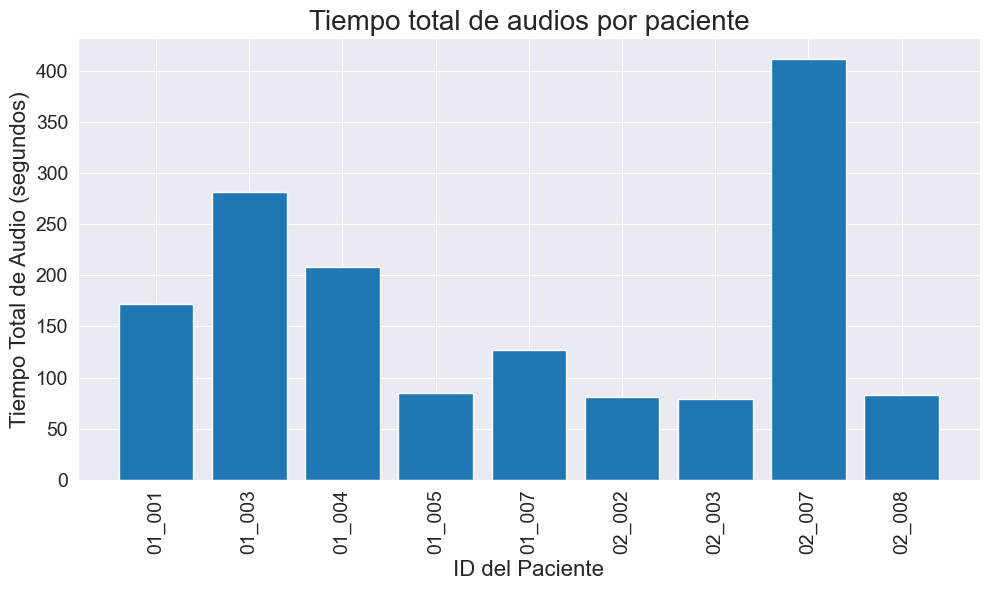

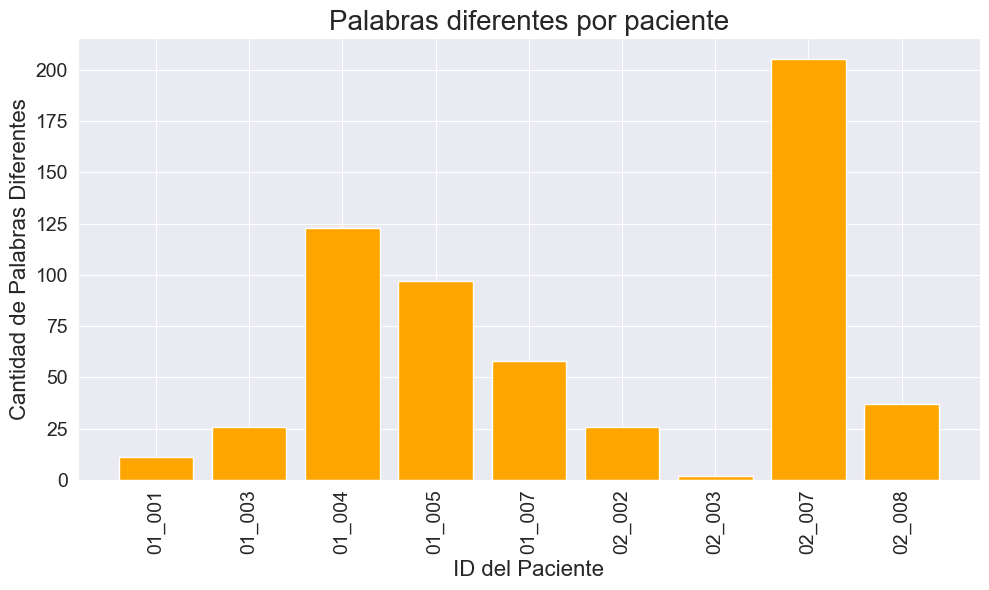

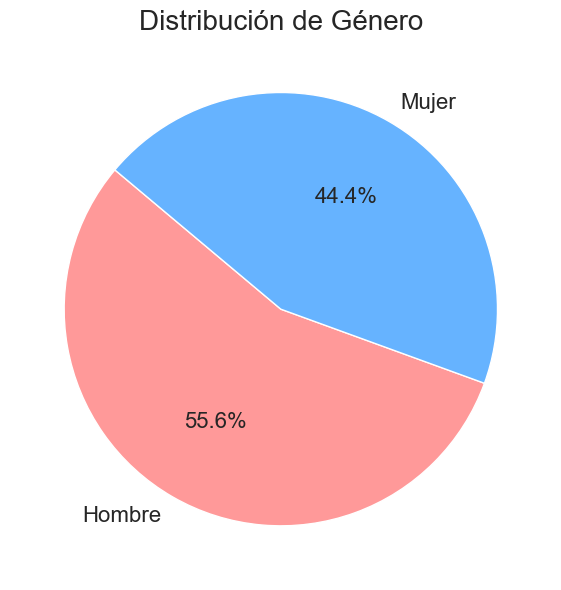

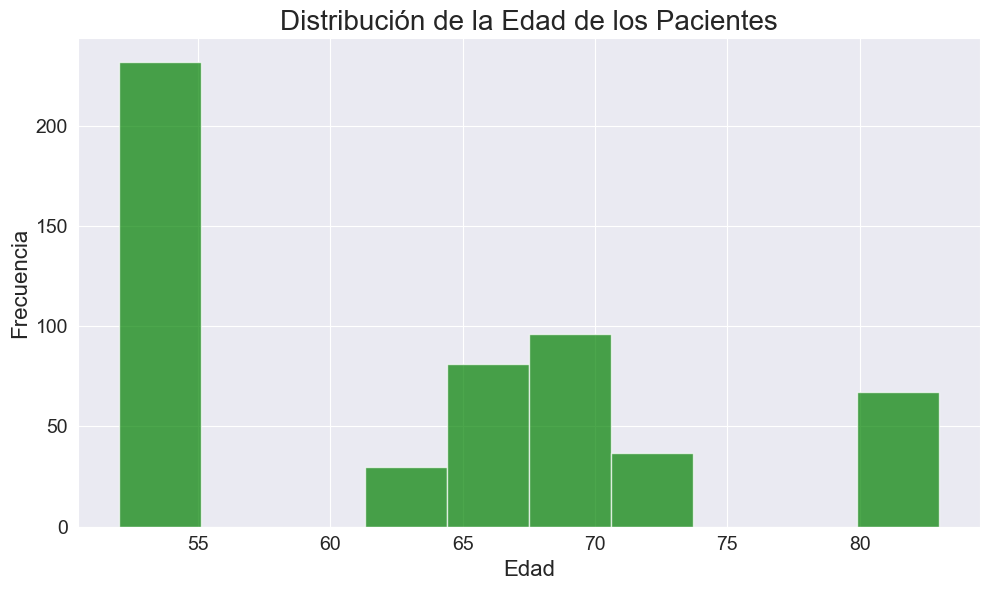

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Definir la ruta base
ruta_base = '/Users/monicaromero/PycharmProjects/afasia_cat/estudio_datos_notebook/'

# Asegurarse de que la ruta exista
os.makedirs(ruta_base, exist_ok=True)

# Asumiendo que df_cruzado ya ha sido creado y procesado como en el código anterior

# 1. Tiempo total de audios por paciente
tiempo_total_por_paciente = df_cruzado.groupby('CIP')['Duración'].sum()

# 2. Cantidad de palabras diferentes por paciente
# Asumiendo que cada fila tiene una marca que representa una palabra o un fragmento
# y que las palabras están separadas por espacios en la columna 'Marca'
palabras_por_paciente = df_cruzado.groupby('CIP')['Marca'].apply(lambda x: len(set(' '.join(x).split())))

# 3. Distribución de pacientes por género
distribucion_genero = df_cruzado.groupby('Gènere')['CIP'].nunique()

# 4. Distribución de la edad
distribucion_edad = df_cruzado['Edat'].dropna()

# Preparar datos para mostrar en tablas
resumen_pacientes = pd.DataFrame({
    'TiempoTotalAudio': tiempo_total_por_paciente,
    'PalabrasDiferentes': palabras_por_paciente
}).reset_index()

# Guardar la tabla de resumen en un archivo CSV
resumen_pacientes.to_csv(os.path.join(ruta_base, 'resumen_pacientes.csv'), index=False)

# Mapear género para que sea legible en gráficos
genero_labels = {1: 'Hombre', 2: 'Mujer'}
distribucion_genero.index = distribucion_genero.index.map(genero_labels)

# Crear gráficos con textos más grandes

# Gráfico de tiempo total de audios por paciente
plt.figure(figsize=(10, 6))
plt.bar(resumen_pacientes['CIP'], resumen_pacientes['TiempoTotalAudio'])
plt.title('Tiempo total de audios por paciente', fontsize=20)
plt.xlabel('ID del Paciente', fontsize=16)
plt.ylabel('Tiempo Total de Audio (segundos)', fontsize=16)
plt.xticks(rotation=90, fontsize=14)  # Aumentar tamaño de los datos en eje X
plt.yticks(fontsize=14)               # Aumentar tamaño de los datos en eje Y
plt.tight_layout()
plt.savefig(os.path.join(ruta_base, 'tiempo_total_por_paciente.png'))

# Gráfico de cantidad de palabras diferentes por paciente
plt.figure(figsize=(10, 6))
plt.bar(resumen_pacientes['CIP'], resumen_pacientes['PalabrasDiferentes'], color='orange')
plt.title('Palabras diferentes por paciente', fontsize=20)
plt.xlabel('ID del Paciente', fontsize=16)
plt.ylabel('Cantidad de Palabras Diferentes', fontsize=16)
plt.xticks(rotation=90, fontsize=14)  # Aumentar tamaño de los datos en eje X
plt.yticks(fontsize=14)               # Aumentar tamaño de los datos en eje Y
plt.tight_layout()
plt.savefig(os.path.join(ruta_base, 'palabras_por_paciente.png'))

# Gráfico de distribución por género
plt.figure(figsize=(6, 6))
distribucion_genero.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140, fontsize=16)
plt.title('Distribución de Género', fontsize=20)
plt.ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(ruta_base, 'distribucion_genero.png'))

# Gráfico de distribución de la edad
plt.figure(figsize=(10, 6))
plt.hist(distribucion_edad, bins=10, color='green', alpha=0.7)
plt.title('Distribución de la Edad de los Pacientes', fontsize=20)
plt.xlabel('Edad', fontsize=16)
plt.ylabel('Frecuencia', fontsize=16)
plt.xticks(fontsize=14)  # Aumentar tamaño de los datos en eje X
plt.yticks(fontsize=14)  # Aumentar tamaño de los datos en eje Y
plt.tight_layout()
plt.savefig(os.path.join(ruta_base, 'distribucion_edad.png'))

# Mostrar las primeras filas de la tabla de resumen
print("Resumen de Pacientes:")
print(resumen_pacientes.head())

# Opcionalmente, puedes mostrar los gráficos directamente en un entorno de Jupyter:
plt.show()  # Esto abrirá todos los gráficos en ventanas emergentes (si usas Jupyter, los mostrará en celdas)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumiendo que df_cruzado ya ha sido creado y procesado como en el código anterior

# 1. Tiempo total de audios por paciente
tiempo_total_por_paciente = df_cruzado.groupby('CIP')['Duración'].sum()

# 2. Cantidad de palabras diferentes por paciente
palabras_por_paciente = df_cruzado.groupby('CIP')['Marca'].apply(lambda x: len(set(' '.join(x).split())))

# Preparar datos para mostrar en tablas
resumen_pacientes = pd.DataFrame({
    'TiempoTotalAudio': tiempo_total_por_paciente,
    'PalabrasDiferentes': palabras_por_paciente
}).reset_index()

# Función para convertir el tiempo de segundos a minutos y segundos
def convertir_tiempo(segundos):
    minutos = segundos // 60
    segundos_restantes = segundos % 60
    return f"{int(minutos)} min {int(segundos_restantes)} sec"

# Aplicar la conversión al tiempo total de audio por paciente
resumen_pacientes['TiempoTotalAudio'] = resumen_pacientes['TiempoTotalAudio'].apply(convertir_tiempo)

# Renombrar columnas para mayor claridad
resumen_pacientes = resumen_pacientes.rename(columns={'CIP': 'ID Paciente', 'TiempoTotalAudio': 'Tiempo Total de Audio', 'PalabrasDiferentes': 'Palabras Diferentes'})

# Guardar la tabla final en un archivo CSV
resumen_pacientes.to_csv('resumen_pacientes_tiempo_palabras.csv', index=False)

# Mostrar la tabla final en la consola
print(resumen_pacientes)


  ID Paciente Tiempo Total de Audio  Palabras Diferentes
0      01_001          2 min 51 sec                   11
1      01_003          4 min 41 sec                   26
2      01_004          3 min 28 sec                  123
3      01_005          1 min 24 sec                   97
4      01_007           2 min 7 sec                   58
5      02_002          1 min 21 sec                   26
6      02_003          1 min 19 sec                    2
7      02_007          6 min 50 sec                  205
8      02_008          1 min 22 sec                   37


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumiendo que df_cruzado ya ha sido creado y procesado como en el código anterior

# 1. Tiempo total de audios por paciente
tiempo_total_por_paciente = df_cruzado.groupby('CIP')['Duración'].sum()

# 2. Cantidad de palabras diferentes por paciente
palabras_por_paciente = df_cruzado.groupby('CIP')['Marca'].apply(lambda x: len(set(' '.join(x).split())))

# 3. QA y Tipo de Afasia por paciente
qa_por_paciente = df_cruzado.groupby('CIP')['QA'].first()
tipus_afasia_por_paciente = df_cruzado.groupby('CIP')['TipusAfàsia'].first()
llengwab_por_paciente = df_cruzado.groupby('CIP')['LLengWAB'].first()

# Preparar datos para mostrar en tablas
resumen_pacientes = pd.DataFrame({
    'TiempoTotalAudio': tiempo_total_por_paciente,
    'PalabrasDiferentes': palabras_por_paciente,
    'QA': qa_por_paciente,
    'TipoAfasia': tipus_afasia_por_paciente,
    'Lengua': llengwab_por_paciente
}).reset_index()

# Función para convertir el tiempo de segundos a horas, minutos y segundos
def convertir_tiempo(segundos):
    horas = segundos // 3600
    minutos = (segundos % 3600) // 60
    segundos_restantes = segundos % 60
    return f"{int(horas)}h {int(minutos)}m {int(segundos_restantes)}s"

# Aplicar la conversión al tiempo total de audio por paciente
resumen_pacientes['TiempoTotalAudio'] = tiempo_total_por_paciente.apply(convertir_tiempo)

# Mapear los códigos de tipo de afasia y lengua a valores legibles
mapeo_tipus_afasia = {
    1: "Motora", 2: "Sensorial", 3: "Global", 4: "Conducción",
    5: "Anómica", 6: "Motora Transcortical", 7: "Sensorial Transcortical"
}

mapeo_llengwab = {1: "Català", 2: "Castellà"}

resumen_pacientes['TipoAfasia'] = resumen_pacientes['TipoAfasia'].map(mapeo_tipus_afasia)
resumen_pacientes['Lengua'] = resumen_pacientes['Lengua'].map(mapeo_llengwab)

# Renombrar columnas para mayor claridad
resumen_pacientes = resumen_pacientes.rename(columns={'CIP': 'ID Paciente', 'TiempoTotalAudio': 'Tiempo Total de Audio', 'PalabrasDiferentes': 'Palabras Diferentes'})

# Guardar la tabla final en un archivo CSV
resumen_pacientes.to_csv('resumen_pacientes_tiempo_palabras_qa_afasia_lengua.csv', index=False)

# Mostrar la tabla final en la consola
resumen_pacientes

,ID Paciente,Tiempo Total de Audio,Palabras Diferentes,QA,TipoAfasia,Lengua
0,01_001,NaN,11,44.3,Motora,Català
1,01_003,NaN,26,34.7,Motora Transcortical,Català
2,01_004,NaN,123,87.7,Motora,Català
3,01_005,NaN,97,94.9,Motora,Català
4,01_007,NaN,58,96.7,Anómica,Català
5,02_002,NaN,26,46.8,Anómica,Castellà
6,02_003,NaN,2,41.2,Motora,Castellà
7,02_007,NaN,205,41.8,Motora Transcortical,Castellà
8,02_008,NaN,37,82.6,Anómica,Castellà


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumiendo que df_cruzado ya ha sido creado y procesado como en el código anterior

# 1. Tiempo total de audios por paciente
tiempo_total_por_paciente = df_cruzado.groupby('CIP')['Duración'].sum()

# 2. Cantidad de palabras diferentes por paciente
palabras_por_paciente = df_cruzado.groupby('CIP')['Marca'].apply(lambda x: len(set(' '.join(x).split())))

# 3. QA y Tipo de Afasia por paciente
qa_por_paciente = df_cruzado.groupby('CIP')['QA'].first()
tipus_afasia_por_paciente = df_cruzado.groupby('CIP')['TipusAfàsia'].first()
llengwab_por_paciente = df_cruzado.groupby('CIP')['LLengWAB'].first()

num_veces_cip = df_cruzado['CIP'].value_counts()

# Función para convertir el tiempo de segundos a horas, minutos y segundos
def convertir_tiempo(segundos):
    horas = segundos // 3600
    minutos = (segundos % 3600) // 60
    segundos_restantes = segundos % 60
    return f"{int(horas)}h {int(minutos)}m {int(segundos_restantes)}s"

# Aplicar la conversión al tiempo total de audio por paciente antes de crear el DataFrame
tiempo_total_por_paciente = tiempo_total_por_paciente.apply(convertir_tiempo)

# Preparar datos para mostrar en tablas
resumen_pacientes = pd.DataFrame({
    'Tiempo Total de Audio': tiempo_total_por_paciente,
    'Palabras Diferentes': palabras_por_paciente,
    'QA': qa_por_paciente,
    'Tipo Afasia': tipus_afasia_por_paciente,
    'Lengua': llengwab_por_paciente,
    'Num transcripciones': num_veces_cip
}).reset_index()

# Mapear los códigos de tipo de afasia y lengua a valores legibles
mapeo_tipus_afasia = {
    1: "Motora", 2: "Sensorial", 3: "Global", 4: "Conducción",
    5: "Anómica", 6: "Motora Transcortical", 7: "Sensorial Transcortical"
}

mapeo_llengwab = {1: "Català", 2: "Castellà"}

resumen_pacientes['Tipo Afasia'] = resumen_pacientes['Tipo Afasia'].map(mapeo_tipus_afasia)
resumen_pacientes['Lengua'] = resumen_pacientes['Lengua'].map(mapeo_llengwab)

# Renombrar columnas para mayor claridad
resumen_pacientes = resumen_pacientes.rename(columns={'CIP': 'ID Paciente'})

resumen_pacientes


,ID Paciente,Tiempo Total de Audio,Palabras Diferentes,QA,Tipo Afasia,Lengua,Num transcripciones
0,01_001,0h 2m 51s,11,44.3,Motora,Català,30
1,01_003,0h 4m 41s,26,34.7,Motora Transcortical,Català,81
2,01_004,0h 3m 28s,123,87.7,Motora,Català,92
3,01_005,0h 1m 24s,97,94.9,Motora,Català,42
4,01_007,0h 2m 7s,58,96.7,Anómica,Català,49
5,02_002,0h 1m 21s,26,46.8,Anómica,Castellà,25
6,02_003,0h 1m 19s,2,41.2,Motora,Castellà,4
7,02_007,0h 6m 50s,205,41.8,Motora Transcortical,Castellà,183
8,02_008,0h 1m 22s,37,82.6,Anómica,Castellà,37


In [ ]:
import pandas as pd

# Asumiendo que ya tienes el DataFrame resumen_pacientes cargado

# Lógica para determinar si es fluente o no fluente
def determinar_fluencia(tipo_afasia):
    tipo_afasia = tipo_afasia.lower()
    if "broca" in tipo_afasia or "motora" in tipo_afasia or "mixta" in tipo_afasia or "global" in tipo_afasia:
        return "No Fluente"
    elif "wernicke" in tipo_afasia or "sensitiva" in tipo_afasia or "anómica" in tipo_afasia or "conducción" in tipo_afasia:
        return "Fluente"
    else:
        return "Desconocido"  # Para cualquier caso no contemplado

# Aplicar la función a la columna 'TipoAfasia'
resumen_pacientes['Fluente/No Fluente'] = resumen_pacientes['Tipo Afasia'].apply(determinar_fluencia)

ruta_guardado = '/Users/monicaromero/PycharmProjects/afasia_cat/estudio_datos_notebook/resumen_pacientes_actualizado.csv'
resumen_pacientes.to_csv(ruta_guardado, index=False)

In [ ]:
resumen_pacientes

,ID Paciente,Tiempo Total de Audio,Palabras Diferentes,QA,Tipo Afasia,Lengua,Num transcripciones,Fluente/No Fluente
0,01_001,0h 2m 51s,11,44.3,Motora,Català,30,No Fluente
1,01_003,0h 4m 41s,26,34.7,Motora Transcortical,Català,81,No Fluente
2,01_004,0h 3m 28s,123,87.7,Motora,Català,92,No Fluente
3,01_005,0h 1m 24s,97,94.9,Motora,Català,42,No Fluente
4,01_007,0h 2m 7s,58,96.7,Anómica,Català,49,Fluente
5,02_002,0h 1m 21s,26,46.8,Anómica,Castellà,25,Fluente
6,02_003,0h 1m 19s,2,41.2,Motora,Castellà,4,No Fluente
7,02_007,0h 6m 50s,205,41.8,Motora Transcortical,Castellà,183,No Fluente
8,02_008,0h 1m 22s,37,82.6,Anómica,Castellà,37,Fluente
